In [3]:
import ccxt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


In [2]:
pip install ccxt

  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ---------------------------------------- 0.0/6.6 MB ? eta -:--:--
   ---------------------------- ----------- 4.7/6.6 MB 23.8 MB/s eta 0:00:01
   ---------------------------------------- 6.6/6.6 MB 20.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 1.3/1.3 MB 22.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   ---------------------------------------- 3.5/3.5 MB 23.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 24.0 MB/s eta 0:00:00

   ----------------------------------------  0/22 [urllib3]
   ----------------------------------------  0/22 [urllib3]
   ----------------------------------------  0/22 [urllib3]
   ----------------------------------------  0/22 [urllib3]
   - ------------------


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:

# ============================================================
# 1. CHARGEMENT DES DONNÉES — Binance API 1h octobre 2025
# ============================================================

def fetch_ohlcv_full(symbol, timeframe='1h', start='2025-10-01', end='2025-11-01'):
    exchange = ccxt.binance()
    since = exchange.parse8601(f'{start}T00:00:00Z')
    until = exchange.parse8601(f'{end}T00:00:00Z')
    
    all_data = []
    while since < until:
        ohlcv = exchange.fetch_ohlcv(symbol, timeframe, since=since, limit=1000)
        if not ohlcv:
            break
        all_data += ohlcv
        since = ohlcv[-1][0] + 1
    
    df = pd.DataFrame(all_data, columns=['timestamp','open','high','low','close','volume'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df.set_index('timestamp', inplace=True)
    df = df[df.index < pd.Timestamp(end)]
    return df

btc = fetch_ohlcv_full('BTC/USDT')
eth = fetch_ohlcv_full('ETH/USDT')

# Log-rendements
btc['returns'] = np.log(btc['close']).diff()
eth['returns'] = np.log(eth['close']).diff()

# Volatilité roulante 24h
btc['vol_24h'] = btc['returns'].rolling(24).std() * np.sqrt(24)
eth['vol_24h'] = eth['returns'].rolling(24).std() * np.sqrt(24)


plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'legend.fontsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 300,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

# Trouver automatiquement le moment exact du crash
# Sur le mois d'octobre 2025

# Pire rendement BTC
worst_btc = btc['returns'].idxmin()
print(f"Pire rendement BTC : {worst_btc} → {btc['returns'].min()*100:.2f}%")

# Pire rendement ETH
worst_eth = eth['returns'].idxmin()
print(f"Pire rendement ETH : {worst_eth} → {eth['returns'].min()*100:.2f}%")

# Top 5 pires rendements BTC
print("\nTop 5 pires heures BTC :")
print(btc['returns'].nsmallest(5) * 100)

# Top 5 pires rendements ETH  
print("\nTop 5 pires heures ETH :")
print(eth['returns'].nsmallest(5) * 100)




Pire rendement BTC : 2025-10-10 20:00:00 → -2.07%
Pire rendement ETH : 2025-10-10 15:00:00 → -4.23%

Top 5 pires heures BTC :
timestamp
2025-10-10 20:00:00   -2.074034
2025-10-30 04:00:00   -1.984502
2025-10-16 15:00:00   -1.807739
2025-10-21 22:00:00   -1.591187
2025-10-17 06:00:00   -1.525185
Name: returns, dtype: float64

Top 5 pires heures ETH :
timestamp
2025-10-10 15:00:00   -4.228956
2025-10-10 20:00:00   -3.209381
2025-10-11 01:00:00   -2.777050
2025-10-16 15:00:00   -2.735097
2025-10-10 22:00:00   -2.431869
Name: returns, dtype: float64


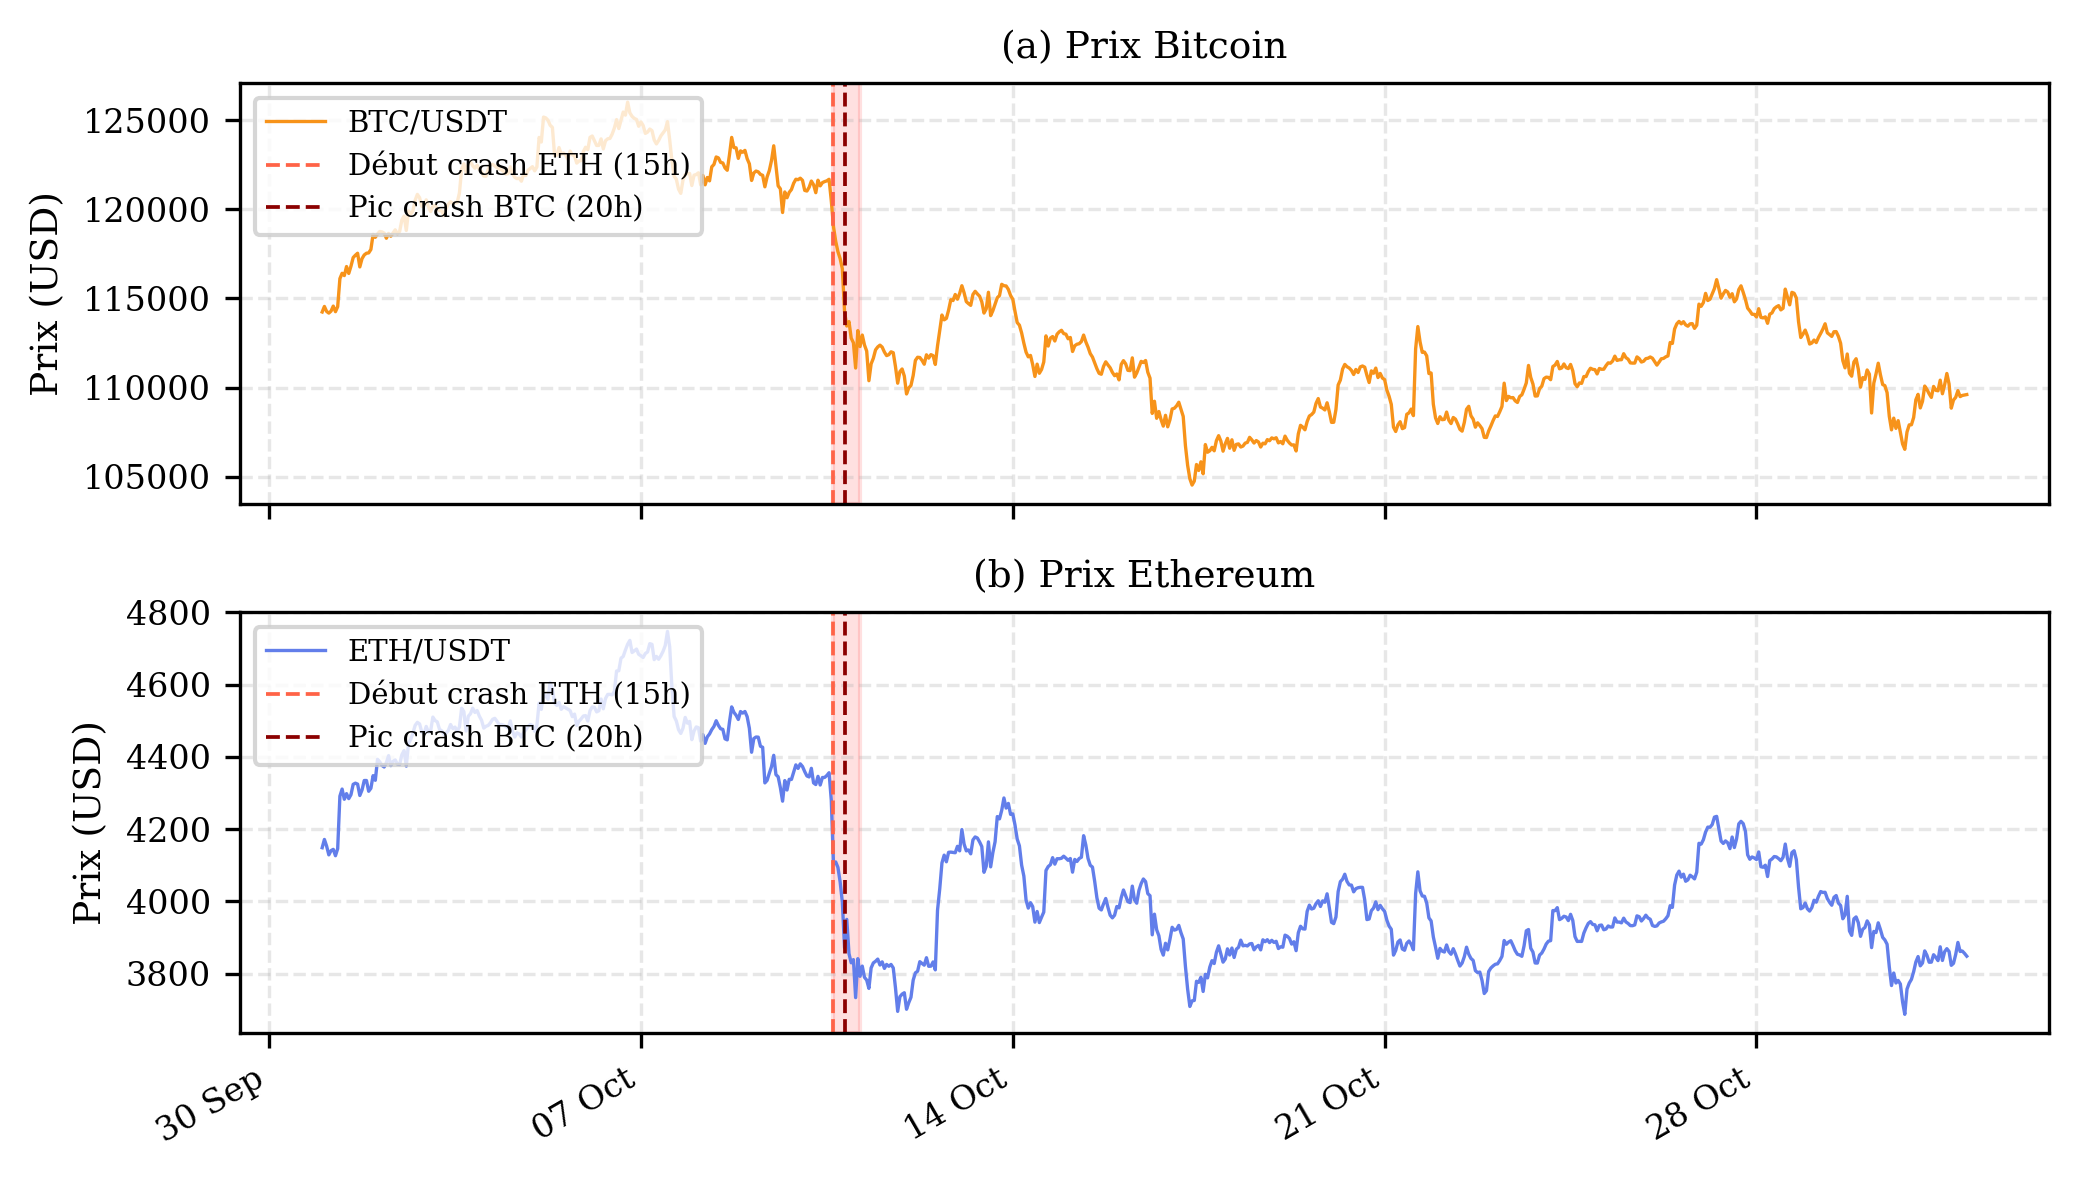

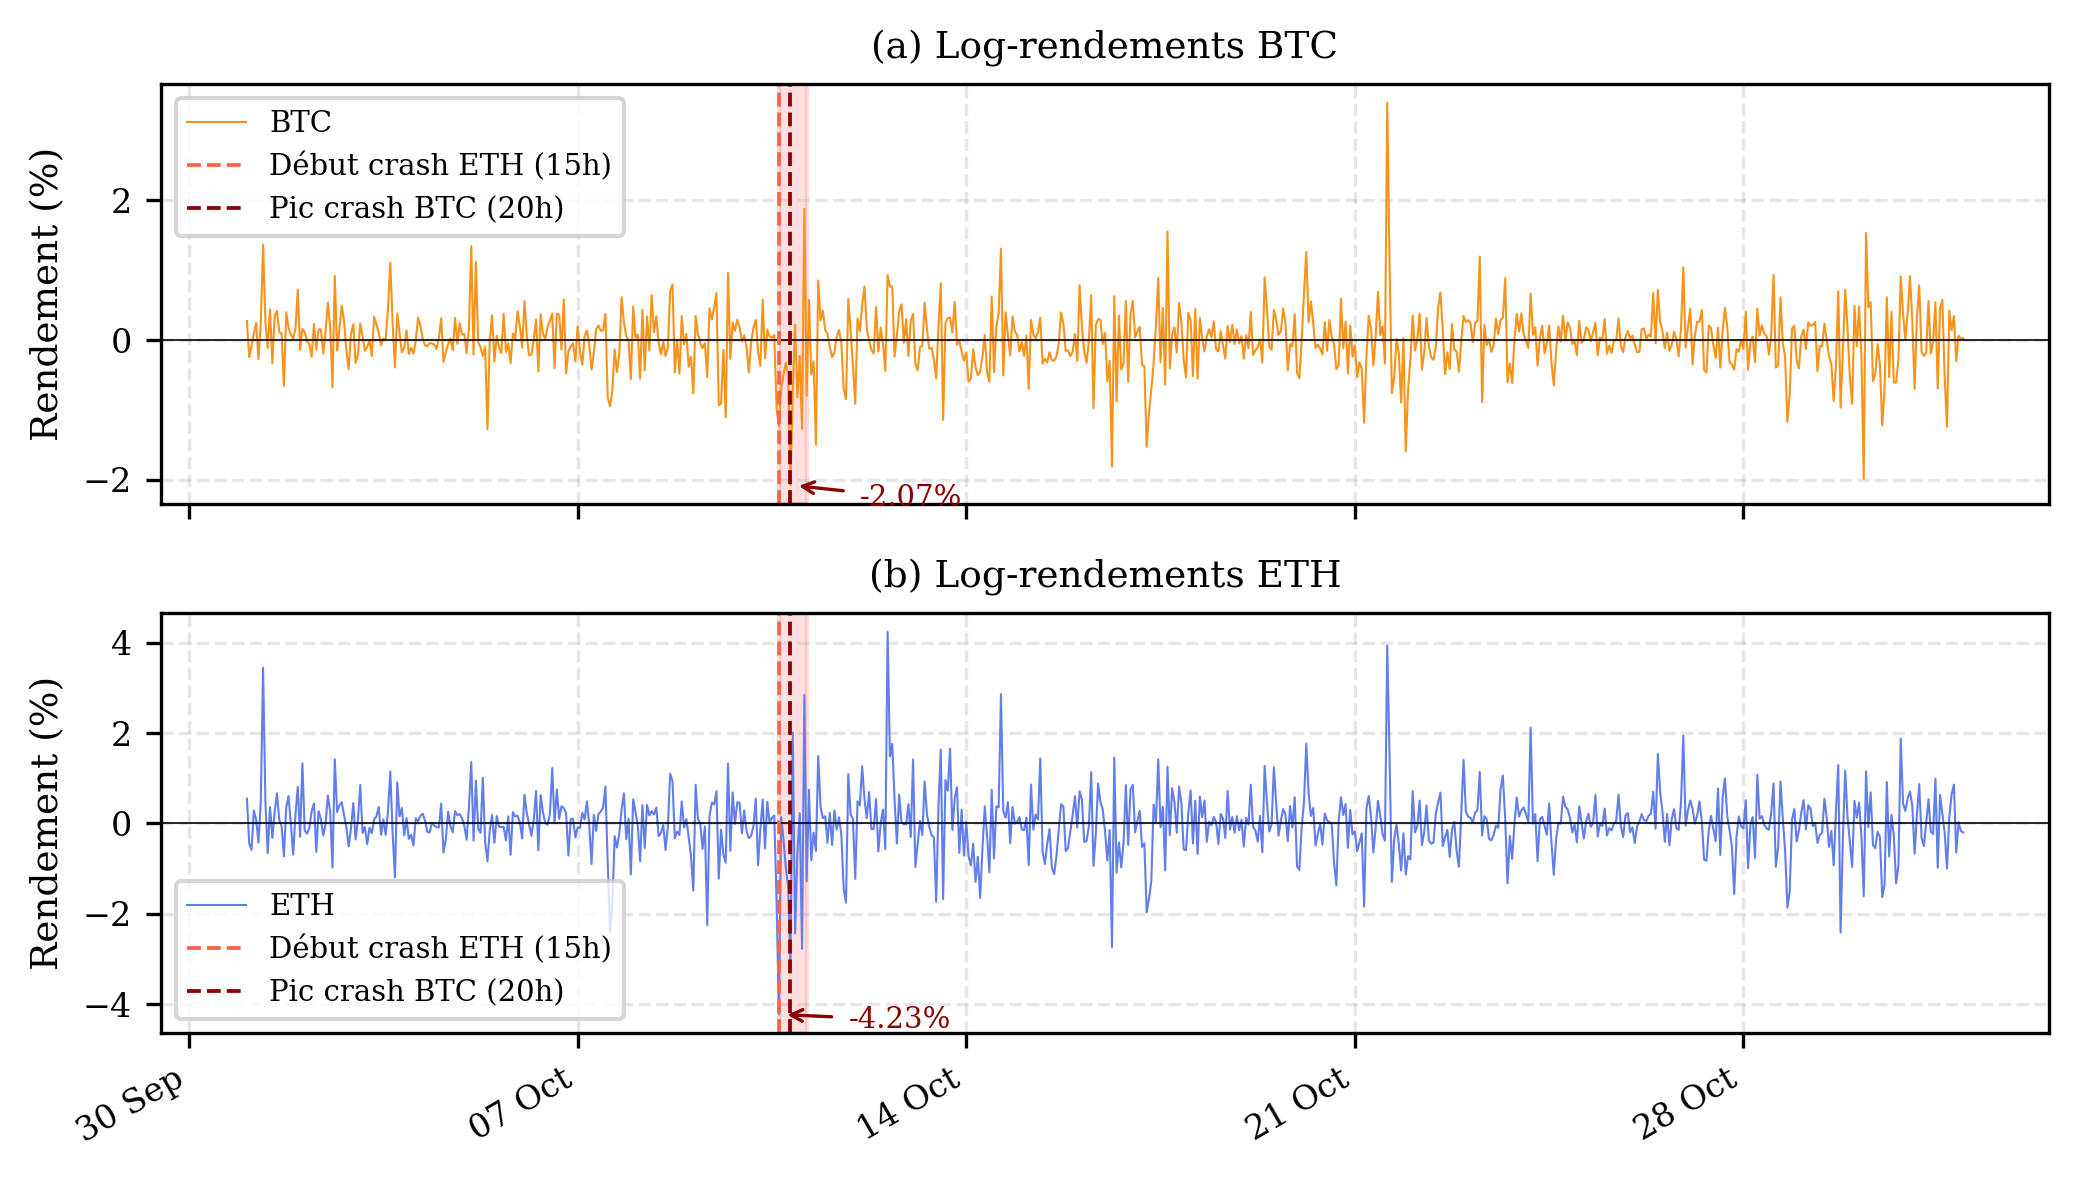

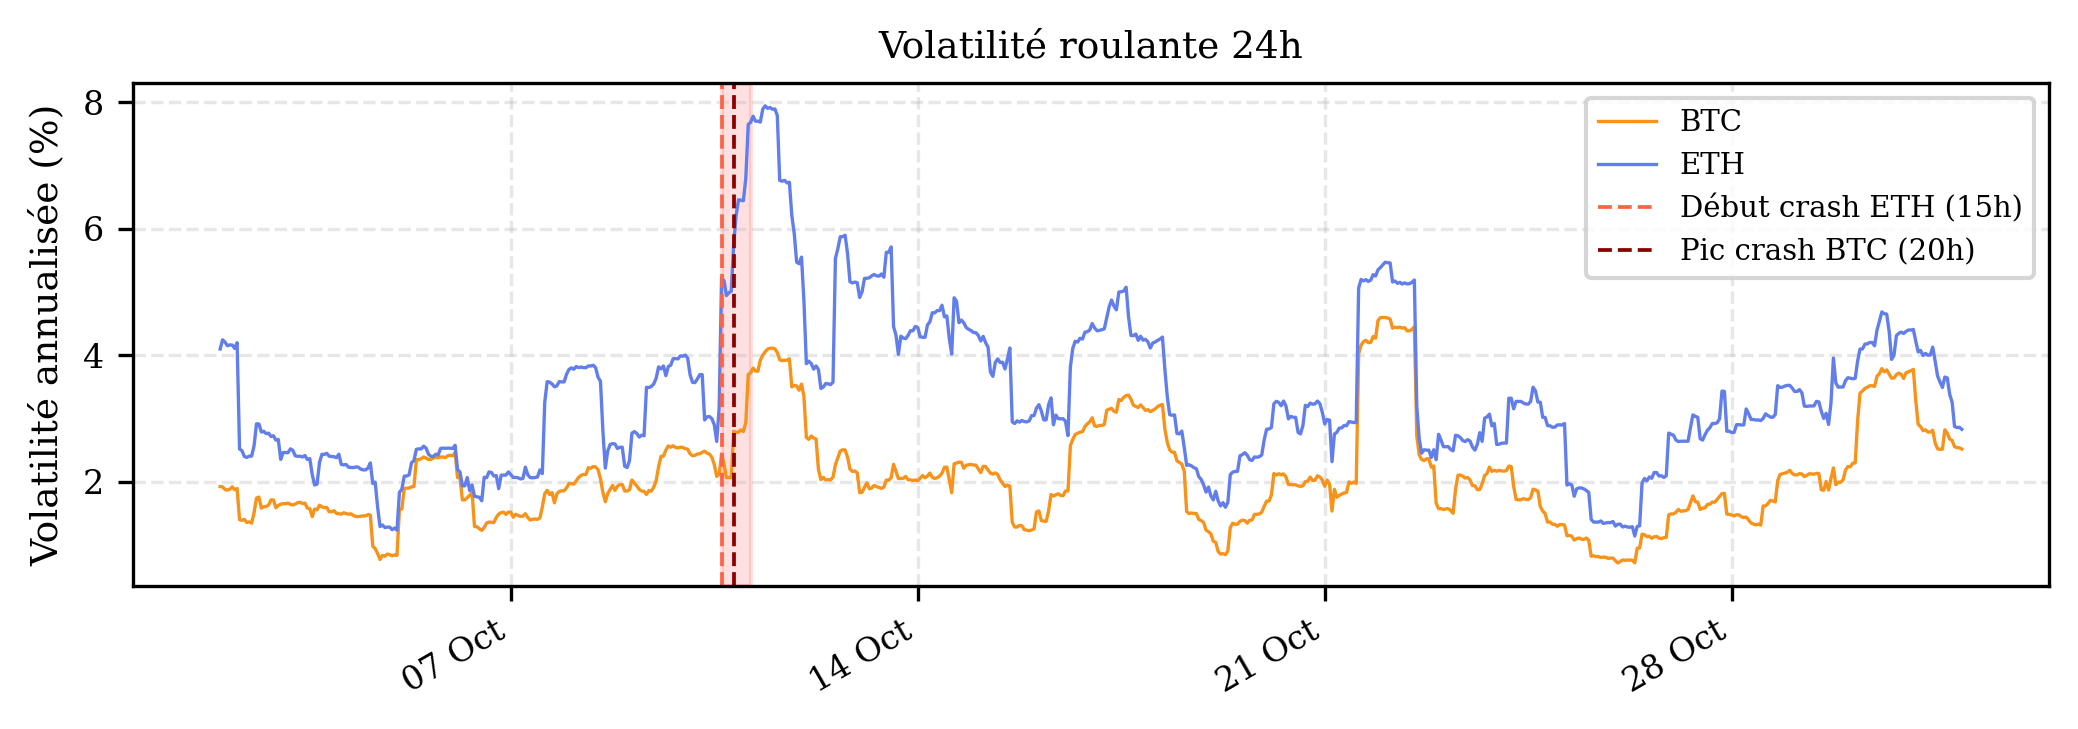

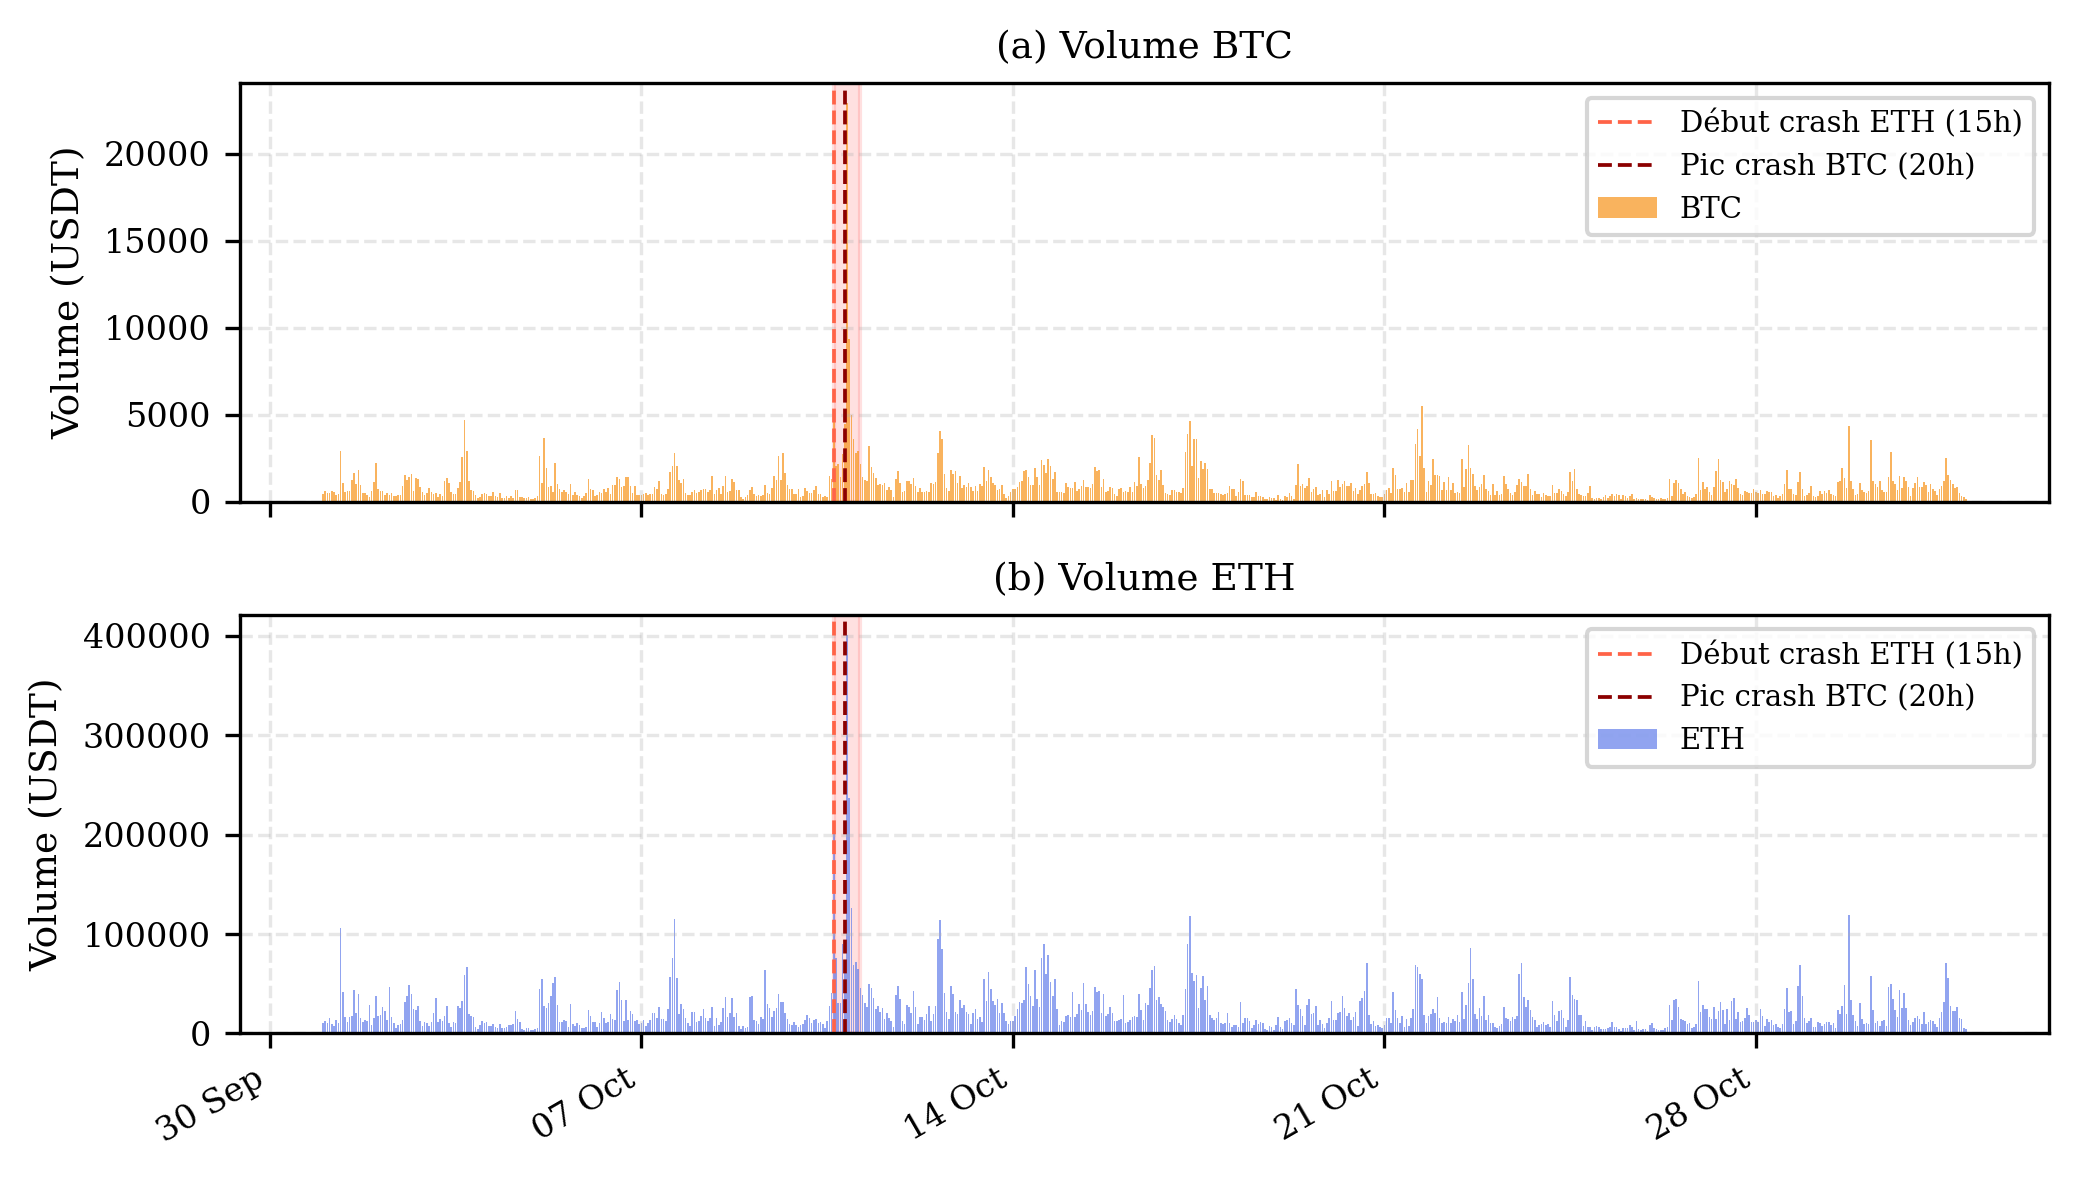

In [11]:
# ============================================================
# DATES DU CRASH 
# ============================================================

crash_start = pd.Timestamp('2025-10-10 15:00:00')  # début ETH
crash_peak  = pd.Timestamp('2025-10-10 20:00:00')  # pic BTC
crash_end   = pd.Timestamp('2025-10-11 03:00:00')  # fin de la cascade

def add_crash_zone(ax):
    """Ajoute la zone de crash sur un axe."""
    ax.axvspan(crash_start, crash_end,
               alpha=0.12, color='red', zorder=0)
    ax.axvline(crash_start, color='tomato', linestyle='--',
               linewidth=0.9, label='Début crash ETH (15h)')
    ax.axvline(crash_peak,  color='darkred', linestyle='--',
               linewidth=0.9, label='Pic crash BTC (20h)')

def format_xaxis(ax):
    """Formate l'axe des dates."""
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# ============================================================
# FIGURE 1 — Prix BTC et ETH
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(7, 4), sharex=True)

axes[0].plot(btc.index, btc['close'], color='#F7931A', linewidth=0.8, label='BTC/USDT')
add_crash_zone(axes[0])
axes[0].set_ylabel('Prix (USD)')
axes[0].set_title('(a) Prix Bitcoin')
axes[0].legend(loc='upper left', fontsize=7)

axes[1].plot(eth.index, eth['close'], color='#627EEA', linewidth=0.8, label='ETH/USDT')
add_crash_zone(axes[1])
axes[1].set_ylabel('Prix (USD)')
axes[1].set_title('(b) Prix Ethereum')
axes[1].legend(loc='upper left', fontsize=7)

format_xaxis(axes[1])
plt.tight_layout()
plt.savefig('fig1_prix.pdf', bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 2 — Log-rendements
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(7, 4), sharex=True)

axes[0].plot(btc.index, btc['returns']*100, color='#F7931A', linewidth=0.5, label='BTC')
axes[0].axhline(0, color='black', linewidth=0.4)
# Annoter le pire rendement BTC
axes[0].annotate(f'{btc["returns"].min()*100:.2f}%',
                 xy=(crash_peak, btc['returns'].min()*100),
                 xytext=(crash_peak + pd.Timedelta(hours=30),
                         btc['returns'].min()*100 - 0.3),
                 fontsize=7, color='darkred',
                 arrowprops=dict(arrowstyle='->', color='darkred', lw=0.8))
add_crash_zone(axes[0])
axes[0].set_ylabel('Rendement (%)')
axes[0].set_title('(a) Log-rendements BTC')
axes[0].legend(fontsize=7)

axes[1].plot(eth.index, eth['returns']*100, color='#627EEA', linewidth=0.5, label='ETH')
axes[1].axhline(0, color='black', linewidth=0.4)
# Annoter le pire rendement ETH
axes[1].annotate(f'{eth["returns"].min()*100:.2f}%',
                 xy=(crash_start, eth['returns'].min()*100),
                 xytext=(crash_start + pd.Timedelta(hours=30),
                         eth['returns'].min()*100 - 0.3),
                 fontsize=7, color='darkred',
                 arrowprops=dict(arrowstyle='->', color='darkred', lw=0.8))
add_crash_zone(axes[1])
axes[1].set_ylabel('Rendement (%)')
axes[1].set_title('(b) Log-rendements ETH')
axes[1].legend(fontsize=7)

format_xaxis(axes[1])
plt.tight_layout()
plt.savefig('fig2_rendements.pdf', bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 3 — Volatilité roulante
# ============================================================

fig, ax = plt.subplots(figsize=(7, 2.5))

ax.plot(btc.index, btc['vol_24h']*100, color='#F7931A', linewidth=0.8, label='BTC')
ax.plot(eth.index, eth['vol_24h']*100, color='#627EEA', linewidth=0.8, label='ETH')
add_crash_zone(ax)
ax.set_ylabel('Volatilité annualisée (%)')
ax.set_title('Volatilité roulante 24h')
ax.legend(fontsize=7)
format_xaxis(ax)

plt.tight_layout()
plt.savefig('fig3_volatilite.pdf', bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 4 — Volume
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(7, 4), sharex=True)

axes[0].bar(btc.index, btc['volume'], color='#F7931A',
            alpha=0.7, width=0.03, label='BTC')
add_crash_zone(axes[0])
axes[0].set_ylabel('Volume (USDT)')
axes[0].set_title('(a) Volume BTC')
axes[0].legend(fontsize=7)

axes[1].bar(eth.index, eth['volume'], color='#627EEA',
            alpha=0.7, width=0.03, label='ETH')
add_crash_zone(axes[1])
axes[1].set_ylabel('Volume (USDT)')
axes[1].set_title('(b) Volume ETH')
axes[1].legend(fontsize=7)

format_xaxis(axes[1])
plt.tight_layout()
plt.savefig('fig4_volume.pdf', bbox_inches='tight')
plt.show()